In [2]:
import pandas as pd

In [3]:
df = pd.read_parquet('/content/drive/MyDrive/Saved from Chrome/jaipur_features_90d.parquet')

In [4]:
df.columns

Index(['temperature_2m', 'relative_humidity_2m', 'precipitation',
       'cloud_cover', 'wind_speed_10m', 'shortwave_radiation',
       'direct_radiation', 'diffuse_radiation', 'solar_output_mw',
       'clear_sky_ghi', 'hour', 'day_of_week', 'month', 'is_daytime',
       'hour sin', 'hour cos', 'month sin', 'month cos', 'solar_lag_1h',
       'solar_lag_24h', 'solar_lag_48h', 'solar_lag_168h',
       'solar_rolling_mean_3h', 'solar_rolling_mean_6h',
       'solar_rolling_std_3h', 'clear_sky_output', 'clear_sky_ratio'],
      dtype='object')

In [5]:
df = df.rename(columns = {
    'hour sin' : 'hour_sin',
    'hour cos' : 'hour_cos',
    'month sin' : 'month_sin',
    'month cos' : 'month_cos'
})

In [9]:
df.columns

Index(['temperature_2m', 'relative_humidity_2m', 'precipitation',
       'cloud_cover', 'wind_speed_10m', 'shortwave_radiation',
       'direct_radiation', 'diffuse_radiation', 'solar_output_mw',
       'clear_sky_ghi', 'hour', 'day_of_week', 'month', 'is_daytime',
       'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'solar_lag_1h',
       'solar_lag_24h', 'solar_lag_48h', 'solar_lag_168h',
       'solar_rolling_mean_3h', 'solar_rolling_mean_6h',
       'solar_rolling_std_3h', 'clear_sky_output', 'clear_sky_ratio'],
      dtype='object')

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [7]:
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = df.iloc[:train_end]
val   = df.iloc[train_end:val_end]
test  = df.iloc[val_end:]

print(f"Train: {len(train)} rows")
print(f"Val:   {len(val)} rows")
print(f"Test:  {len(test)} rows")

Train: 1394 rows
Val:   299 rows
Test:  299 rows


In [11]:
def create_sequences(X, y, lookback=24):

    X_seq, y_seq = [], []

    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)


feature_cols = ['shortwave_radiation',
    'cloud_cover',
    'temperature_2m',
    'relative_humidity_2m',
    'wind_speed_10m',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'solar_lag_1h',
    'solar_lag_24h',
    'solar_lag_48h',
    'solar_lag_168h',
    'solar_rolling_mean_3h',
    'solar_rolling_mean_6h',
    'solar_rolling_std_3h',
    'clear_sky_ratio']

target_col = 'solar_output_mw'
LOOKBACK = 24

X_train_seq, y_train_seq = create_sequences(
    train[feature_cols].values,
    train[target_col].values,
    LOOKBACK
)

X_val_seq, y_val_seq = create_sequences(
    val[feature_cols].values,
    val[target_col].values,
    LOOKBACK
)

X_test_seq, y_test_seq = create_sequences(
    test[feature_cols].values,
    test[target_col].values,
    LOOKBACK
)

print("X_train_seq shape:", X_train_seq.shape)
print("X_val_seq shape:  ", X_val_seq.shape)
print("X_test_seq shape: ", X_test_seq.shape)

X_train_seq shape: (1370, 24, 17)
X_val_seq shape:   (275, 24, 17)
X_test_seq shape:  (275, 24, 17)


In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(
    train[feature_cols].values
)
y_train_scaled = scaler_y.fit_transform(
    train[[target_col]].values
)

X_val_scaled = scaler_X.transform(val[feature_cols].values)
y_val_scaled = scaler_y.transform(val[[target_col]].values)

X_test_scaled = scaler_X.transform(test[feature_cols].values)
y_test_scaled = scaler_y.transform(test[[target_col]].values)

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled, y_train_scaled.flatten(),
    LOOKBACK
)
X_val_seq, y_val_seq = create_sequences(
    X_val_scaled, y_val_scaled.flatten(),
    LOOKBACK
)
X_test_seq, y_test_seq = create_sequences(
    X_test_scaled, y_test_scaled.flatten(),
    LOOKBACK
)

print("Scaling complete")
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq range:", y_train_seq.min().round(2),
      "to", y_train_seq.max().round(2))

Scaling complete
X_train_seq shape: (1370, 24, 17)
y_train_seq range: 0.0 to 1.0


In [14]:
n_features = X_train_seq.shape[2]
n_lookback = X_train_seq.shape[1]

model_lstm = Sequential([
    LSTM(64,
         return_sequences=True,
         input_shape=(n_lookback, n_features)),
    Dropout(0.2),


    LSTM(32,
         return_sequences=False),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

model_lstm.compile(
    optimizer='adam',
    loss='mae'
)

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,953 (132.63 KB)

 Trainable params: 33,953 (132.63 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model_lstm.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stop],
    verbose=1
)

print("Training complete")

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 0.1580 - val_loss: 0.0538
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0656 - val_loss: 0.0315
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0518 - val_loss: 0.0197
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0452 - val_loss: 0.0279
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0415 - val_loss: 0.0232
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0372 - val_loss: 0.0123
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0389 - val_loss: 0.0446
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0429 - val_loss: 0.0144
Epoch 9/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0360 - val_loss: 0.0192
Epoch 10/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0341 - val_loss: 0.0160
Epoch 11/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0355 - val_loss: 0.0296
Epoch 12/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_scaled = model_lstm.predict(X_val_seq)

y_pred_lstm = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_actual = scaler_y.inverse_transform(
    y_val_seq.reshape(-1,1)
).flatten()

mae  = mean_absolute_error(y_actual, y_pred_lstm)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred_lstm))

daytime_mask = y_actual > 1.0
mape = np.mean(
    np.abs((y_actual[daytime_mask] - y_pred_lstm[daytime_mask]) /
            y_actual[daytime_mask])
) * 100

print("LSTM Results:")
print(f"MAE:  {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape:.2f}%")

print("\nXGBoost Results (for comparison):")
print("MAE:  0.25 MW")
print("RMSE: 0.48 MW")
print("MAPE: 2.17%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
LSTM Results:
MAE:  0.60 MW
RMSE: 0.99 MW
MAPE: 5.31%

XGBoost Results (for comparison):
MAE:  0.25 MW
RMSE: 0.48 MW
MAPE: 2.17%


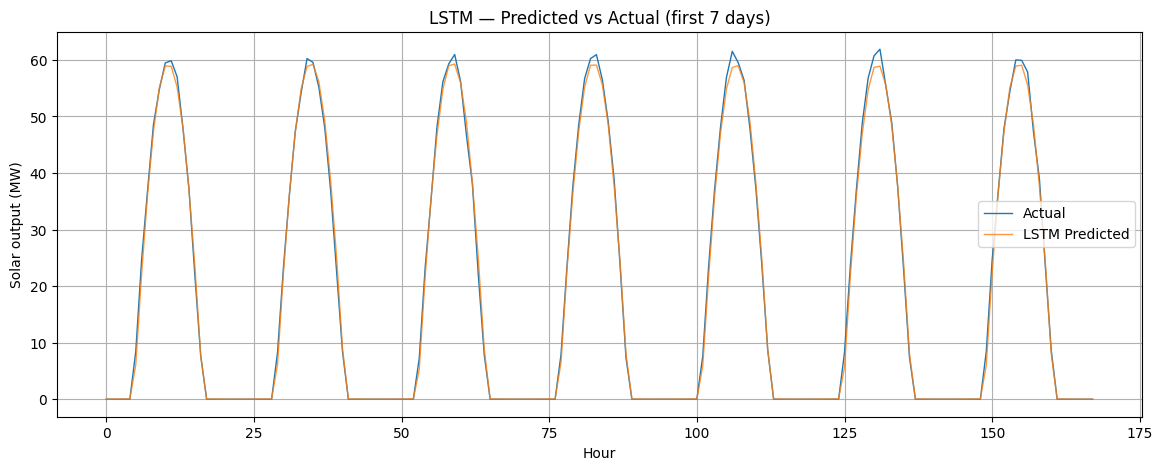

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(y_actual[:168], label='Actual', linewidth=1)
plt.plot(y_pred_lstm[:168], label='LSTM Predicted',
         linewidth=1, alpha=0.8)
plt.title('LSTM — Predicted vs Actual (first 7 days)')
plt.xlabel('Hour')
plt.ylabel('Solar output (MW)')
plt.legend()
plt.grid(True)
plt.show()

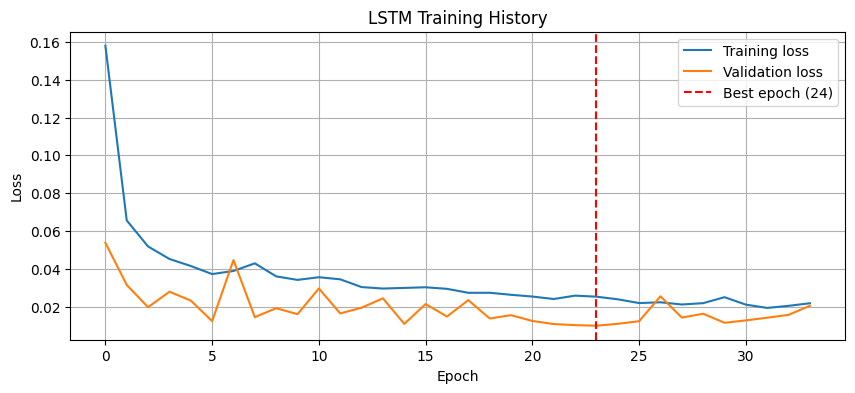

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.axvline(x=23, color='red', linestyle='--',
            label='Best epoch (24)')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
model_lstm.save(
    '/content/drive/MyDrive/lstm_solar_v1.keras'
)
print("LSTM model saved to Drive")

LSTM model saved to Drive
